# Rede escolar — ENEM 2025

Entre os registros com informação escolar, como as distribuições variam por rede? Leia primeiro a cobertura: dependência administrativa não está disponível para toda a base. Dados escolares provenientes do Censo Escolar 2025, com seleção de possíveis concluintes; veja o Leia_Me e o contrato `../docs/contrato_analitico_rede_escolar_2025.md`.

Execute após 01 (trusted v4). As demais auditorias 02–05 devem ser renovadas antes da apresentação. DuckDB: 256 MB/uma thread; Pandas recebe somente agregados. Não há join com PARTICIPANTES.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image
raiz=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'src/rede_escolar.py').is_file())
if str(raiz) not in sys.path:
    sys.path.insert(0,str(raiz))
from src.rede_escolar_execucao import executar_rede_escolar
from src.rede_escolar_graficos import gerar_grafico_rede_escolar
escolar, auditoria_rede=executar_rede_escolar(raiz)
assert auditoria_rede['sha256_antes']==auditoria_rede['sha256_depois']
assert auditoria_rede['controles']['reconciliacao_total']


## Cobertura antes da comparação

Códigos: 1 Federal, 2 Estadual, 3 Municipal, 4 Privada. Federal integra a rede pública, mas as quatro categorias ficam separadas nesta análise. Nulos não são imputados nem classificados como públicos ou privados; códigos inválidos bloqueiam a análise.


In [2]:
display(pd.DataFrame(escolar['cobertura']).drop(columns='codigo').round(2))
print({k:v for k,v in auditoria_rede['controles'].items() if k!='por_area_rede'})


,rede,registros,pct_base
0,Federal,74649,1.55
1,Estadual,1382565,28.74
2,Municipal,9015,0.19
3,Privada,272799,5.67
4,Sem informação,3071744,63.85


{'total_base': 4810772, 'rede_valida': 1739028, 'rede_nula': 3071744, 'rede_invalida': 0, 'pct_rede_valida': 36.148626457458384, 'reconciliacao_total': True}


## Distribuições de notas nas quatro áreas

Mesmo filtro nacional: presença=1 e nota disponível na própria área; zero incluído. Quartis tipo 7 e médias diretamente dos registros. As bases diferem por rede e podem diferir por área. Não é um ranking de escolas, medida de qualidade, efeito causal ou indicador de renda. A pequena base municipal exige cautela.


,rede,area,total_base,elegiveis,zeros_elegiveis,media,q1,mediana,q3,minimo_observado,maximo_observado
0,Federal,CN,74649,68618,3,535.70,489.20,538.50,584.30,0.0,858.7
1,Federal,CH,74649,70097,96,547.87,497.00,558.40,605.40,0.0,856.4
2,Federal,LC,74649,70097,29,563.98,529.30,569.50,605.60,0.0,794.5
3,Federal,MT,74649,68618,3,586.95,489.40,588.50,680.40,0.0,980.3
4,Estadual,CN,1382565,964885,145,472.61,422.60,472.70,520.20,0.0,858.7
5,Estadual,CH,1382565,1018248,2222,483.67,427.70,482.60,539.40,0.0,832.8
6,Estadual,LC,1382565,1018248,574,508.20,466.40,516.20,557.00,0.0,794.5
7,Estadual,MT,1382565,964885,215,480.63,397.40,462.30,548.60,0.0,980.3
8,Municipal,CN,9015,6619,1,500.20,454.40,503.50,547.70,0.0,793.1
9,Municipal,CH,9015,6952,18,517.05,462.78,525.25,574.42,0.0,741.8


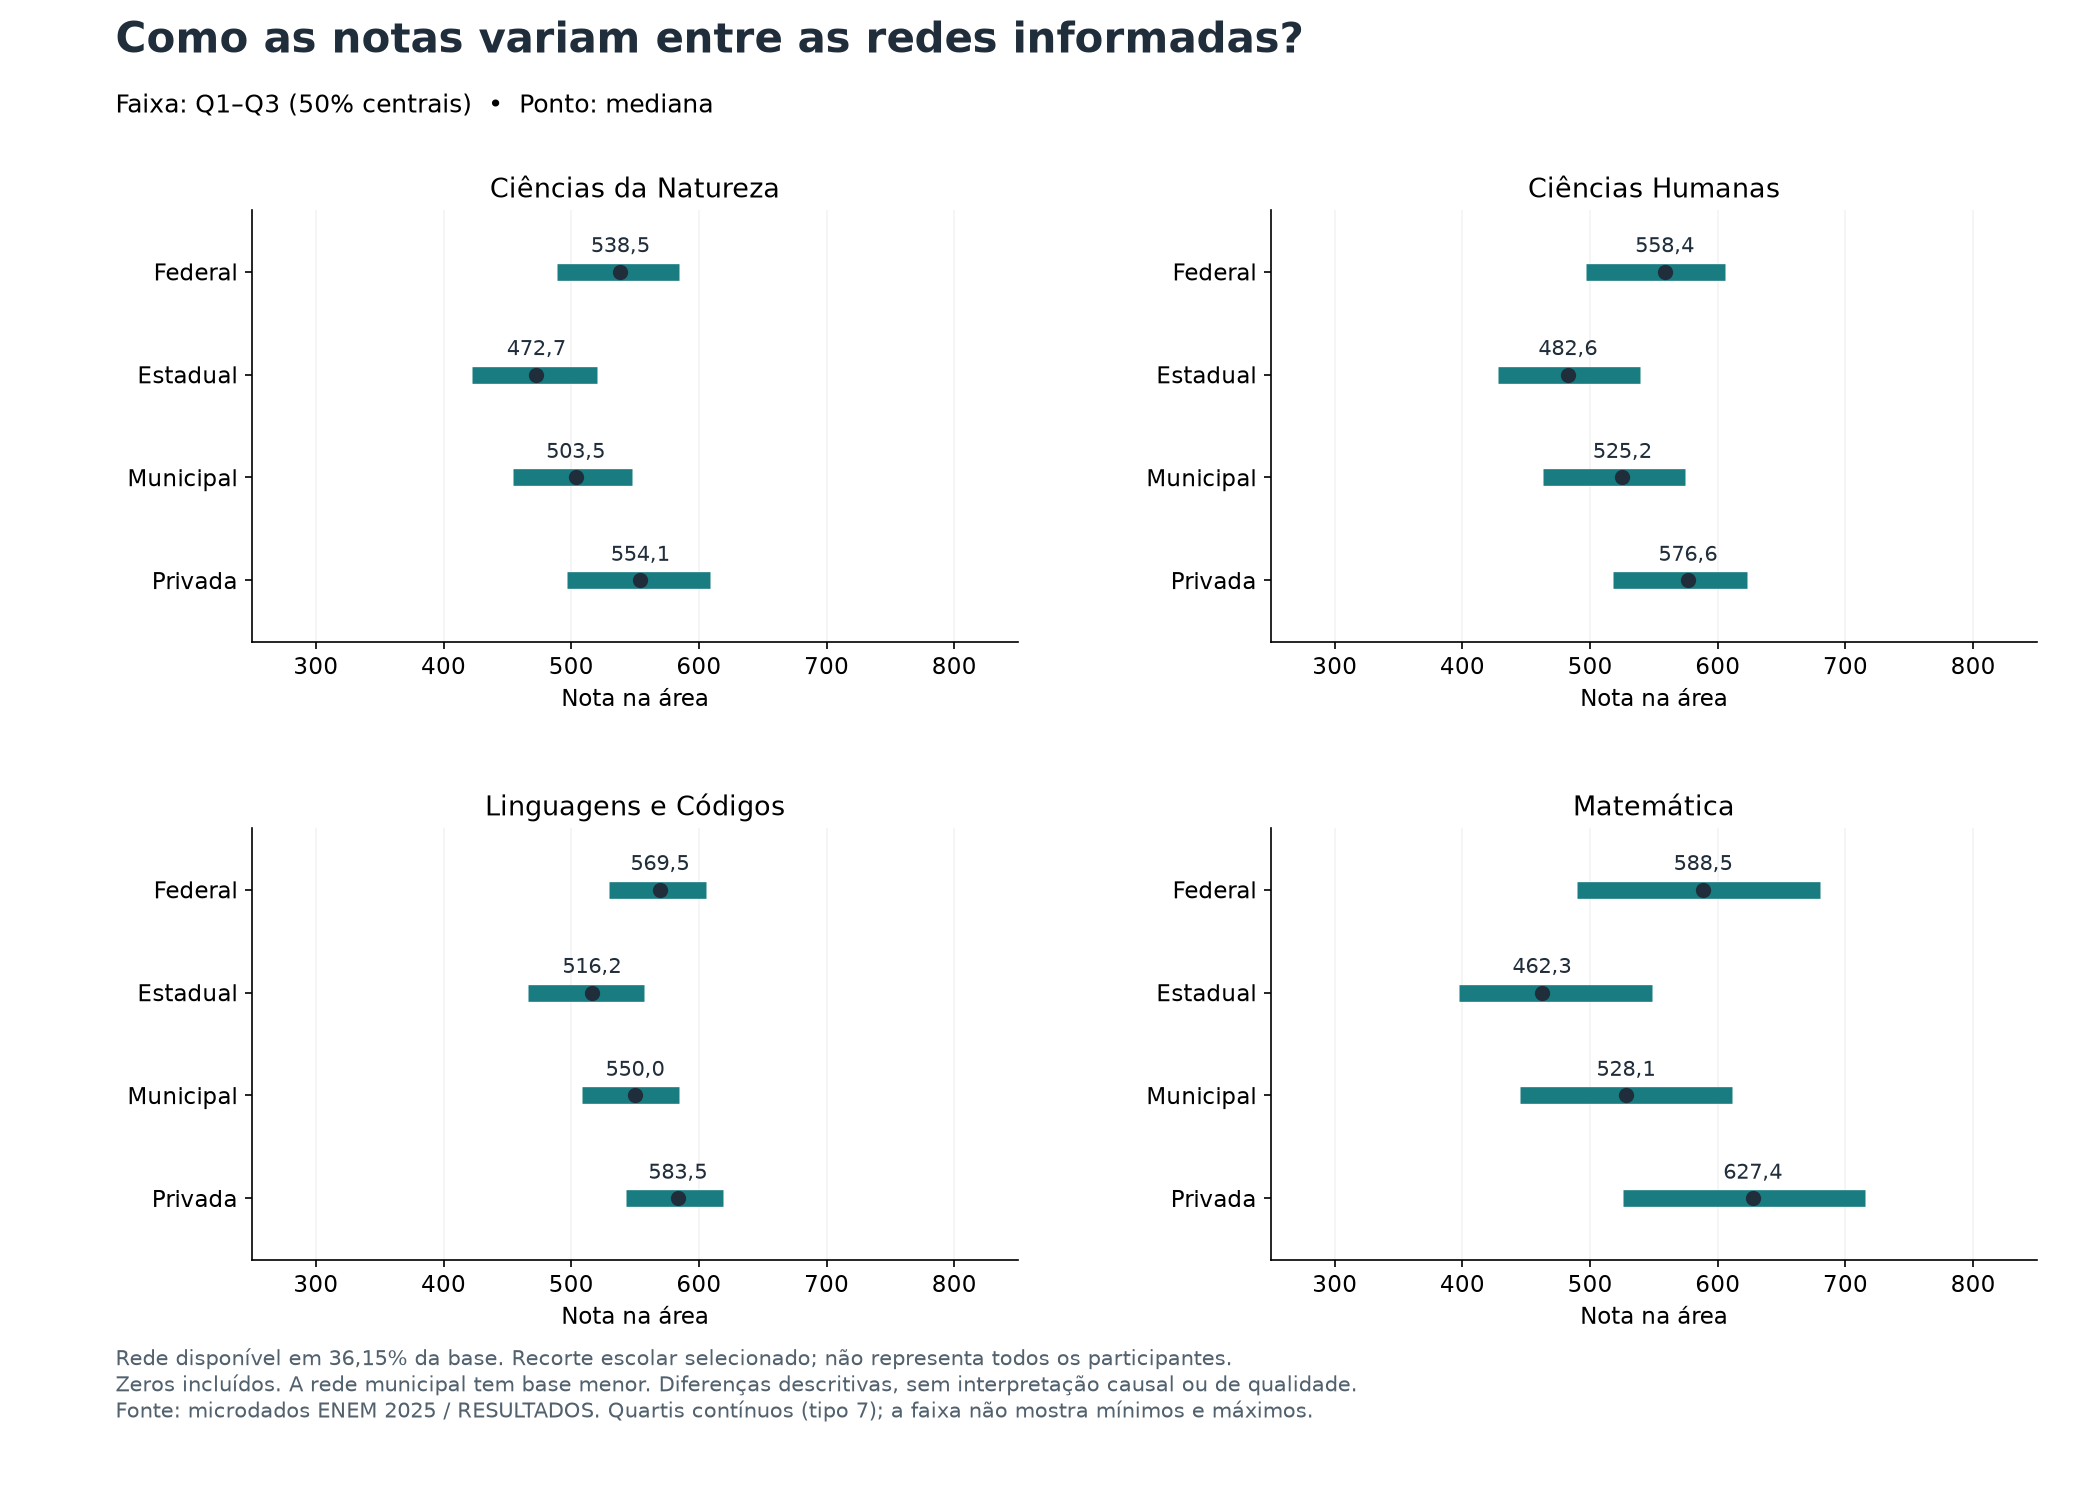

In [1]:
colunas=['rede','area','total_base','elegiveis','zeros_elegiveis','media','q1','mediana','q3','minimo_observado','maximo_observado']
display(pd.DataFrame(escolar['desempenho'])[colunas].round(2))
figura_rede=gerar_grafico_rede_escolar(escolar,raiz/'apresentacao/graficos')
display(Image(filename=str(figura_rede)))


## Limites e próximo passo

Informação escolar é um recorte selecionado: o Leia_Me descreve vínculo por CPF ao Censo, seleção de etapas de possíveis concluintes e preferência por rede pública, ensino regular, maior carga horária e município declarado quando há matrículas em escolas distintas. O CPF não está sendo usado neste projeto. O código da escola não foi adicionado à trusted.

Diferenças de perfil, seleção e participação podem acompanhar os contrastes observados; esta descrição não identifica suas causas. Próximo passo: perfil de renda em PARTICIPANTES, independente das notas de RESULTADOS, que não têm chave comum.
